In [1]:
import pandas as pd

In [2]:
base = pd.read_csv('base_file.csv')
enquiry = pd.read_csv('enquiry_data.csv')
tradeline = pd.read_csv('tradeline_data.csv')


base.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24800 entries, 0 to 24799
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Client_ID  24800 non-null  int64  
 1   Applied    24751 non-null  float64
 2   Approved   24800 non-null  int64  
dtypes: float64(1), int64(2)
memory usage: 581.4 KB


Data Exploration

In [3]:
# Client Across all datasets
tradeline_client = set(tradeline['Client_ID'].unique())
base_client = set(base['Client_ID'].unique())
enquiry_client = set(enquiry['Client_ID'].unique()) 

client_in_tradeline_not_base = tradeline_client - base_client
client_in_tradeline_not_enquiry = tradeline_client - enquiry_client

missing_from_base_or_enquiry = client_in_tradeline_not_base | client_in_tradeline_not_enquiry

all_clients = base_client | enquiry_client | tradeline_client

missing_percentage_of_clients = len(missing_from_base_or_enquiry) / len(all_clients) * 100

print(f"Total clients in tradeline: {len(tradeline_client)}")
print(f"Total clients in base: {len(base_client)}")
print(f"Total clients in enquiry: {len(enquiry_client)}")
print(f"Missing clients from either base or enquiry: {missing_percentage_of_clients:.2f}%")



Total clients in tradeline: 25000
Total clients in base: 24800
Total clients in enquiry: 24500
Missing clients from either base or enquiry: 2.78%


In [4]:
# find Client duplicates and differences across datasets
duplicate_clients_in_tradeline = tradeline[tradeline.duplicated(subset='Client_ID', keep=False)]
duplicate_clients_in_base = base[base.duplicated(subset='Client_ID', keep=False)]
duplicate_clients_in_enquiry = enquiry[enquiry.duplicated(subset='Client_ID', keep=False)]

print(f"Duplicate clients in tradeline: {len(duplicate_clients_in_tradeline)}")
print(f"Duplicate clients in base: {len(duplicate_clients_in_base)}")  
print(f"Duplicate clients in enquiry: {len(duplicate_clients_in_enquiry)}")  

Duplicate clients in tradeline: 0
Duplicate clients in base: 0
Duplicate clients in enquiry: 0


In [5]:
# clients with missing key data
def check_missing(base, enquiry, tradeline):
    results = {}

    def missing_in_dataset(df, dataset_name, critical_columns):
        missing_clients = df[critical_columns].isnull().sum()
        missing_percentage = round((missing_clients / len(df)) * 100, 2)

        return {
            "dateset_name": dataset_name,
            "missing_clients": missing_clients,
            "missing_percentage": missing_percentage
        }
    
    results['base'] = missing_in_dataset(base, 'base', ['Applied', 'Approved'])
    results['enquiry'] = missing_in_dataset(enquiry, 'enquiry', ['Total_Enquiry_6m_In'])
    results['tradeline'] = missing_in_dataset(tradeline, 'tradeline', ['Total_Tradelines_6m_In'])

    return results

In [6]:
results = check_missing(base, enquiry, tradeline)

print("Base")
print(f"Missing clients: {results['base']['missing_clients']}")
print(f"Missing percentage: {results['base']['missing_percentage']}%")

print("Enquiry")
print(f"Missing clients: {results['enquiry']['missing_clients']}")
print(f"Missing percentage: {results['enquiry']['missing_percentage']}%")

print("Tradeline")
print(f"Missing clients: {results['tradeline']['missing_clients']}")
print(f"Missing percentage: {results['tradeline']['missing_percentage']}%")

Base
Missing clients: Applied     49
Approved     0
dtype: int64
Missing percentage: Applied     0.2
Approved    0.0
dtype: float64%
Enquiry
Missing clients: Total_Enquiry_6m_In    367
dtype: int64
Missing percentage: Total_Enquiry_6m_In    1.5
dtype: float64%
Tradeline
Missing clients: Total_Tradelines_6m_In    200
dtype: int64
Missing percentage: Total_Tradelines_6m_In    0.8
dtype: float64%


In [7]:
# validate tradeline data for inconsistencies
invalid_tradeline = tradeline[
    (tradeline['Total_Tradelines_6m_In'] > tradeline['Total_Tradelines_1y_In']) &
    (tradeline['Total_Tradelines_1y_In'] > tradeline['Total_Tradelines_2y_In'])
]

inconsistent_tradeline_count = len(invalid_tradeline)
inconsistent_tradeline_percentage = round((inconsistent_tradeline_count / len(tradeline)) * 100, 2)

print(f"Inconsistent tradeline records: {inconsistent_tradeline_count}")
print(f"Inconsistent tradeline percentage: {inconsistent_tradeline_percentage}%")



Inconsistent tradeline records: 0
Inconsistent tradeline percentage: 0.0%


In [8]:
# validate enquiry data for inconsistencies
invaild_enquiry = enquiry[
    (enquiry['Total_Enquiry_6m_In'] > enquiry['Total_Enquiry_1y_In']) &
    (enquiry['Total_Enquiry_1y_In'] > enquiry['Total_Enquiry_2y_In'])
]

inconsistent_enquiry_count = len(invaild_enquiry)
inconsistent_enquiry_percentage = round((inconsistent_enquiry_count / len(enquiry)) * 100, 2)

print(f"Inconsistent enquiry records: {inconsistent_enquiry_count}")
print(f"Inconsistent enquiry percentage: {inconsistent_enquiry_percentage}%")

Inconsistent enquiry records: 0
Inconsistent enquiry percentage: 0.0%


In [9]:
# outliers in tradeline data
Q1 = tradeline['Total_Tradelines_6m_In'].quantile(0.25)
Q3 = tradeline['Total_Tradelines_6m_In'].quantile(0.75)

IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

Q2 = tradeline['Total_Tradelines_6m_In'].median()
outliers = tradeline[tradeline['Total_Tradelines_6m_In'] > upper_bound]
num_outliers = outliers['Client_ID'].nunique()

print(Q1, Q2, Q3)
print(IQR)
print(upper_bound)
print(num_outliers)
print(outliers['Client_ID'].unique())

5.0 10.0 14.0
9.0
27.5
0
[]


In [10]:
# loan approval errors
approval_errors = base[
    (base['Applied'] < base['Approved'])
]

approval_errors_count = len(approval_errors)
approval_errors_percentage = round((approval_errors_count / len(base)) * 100, 2)

print(f"Loan approval errors: {approval_errors_count}")
print(f"Loan approval errors percentage: {approval_errors_percentage}%")

Loan approval errors: 0
Loan approval errors percentage: 0.0%


In [11]:
# value distribution for categorical columns
applied_unique = sorted(base['Applied'].unique(), key=lambda x: (pd.isna(x), x))
approved_unique = sorted(base['Approved'].unique(), key=lambda x: (pd.isna(x), x))

print("Unique Values in Applied:", applied_unique)
print("Unique Values in Approved:", approved_unique)


Unique Values in Applied: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0), np.float64(4.0), np.float64(nan)]
Unique Values in Approved: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4)]


Data Cleaning

In [12]:
# handling missing values in critical columns
def handle_missing_values(base, enquiry, tradeline):
    
    tradeline_missing_pct = tradeline['Total_Tradelines_6m_In'].isna().mean() * 100
    if tradeline_missing_pct < 2:
        median_val = tradeline['Total_Tradelines_6m_In'].median()
        tradeline['Total_Tradelines_6m_In'].fillna(median_val, inplace=True)

    enquiry_missing_pct = enquiry['Total_Enquiry_6m_In'].isna().mean() * 100
    if enquiry_missing_pct < 2:
        median_val = enquiry['Total_Enquiry_6m_In'].mean()
        enquiry['Total_Enquiry_6m_In'].fillna(median_val, inplace=True)

    base.loc[base['Applied'].isna() & base['Approved'].notna(), 'Applied'] = base['Approved']
    base.dropna(subset=['Applied', 'Approved'], how='all', inplace=True)

    critical_cols = ['Total_Tradelines_6m_In', 'Total_Enquiry_6m_In', 'Applied', 'Approved']

    verify = {
        "base" : base[critical_cols[-2:]].isna().sum(),
        "enquiry" : enquiry[['Total_Enquiry_6m_In']].isna().sum(),
        "tradeline" : tradeline[['Total_Tradelines_6m_In']].isna().sum()
    }
    return base, enquiry, tradeline, verify

base_clean, enquiry_clean, tradeline_clean, check = handle_missing_values(base, enquiry, tradeline)

print("Verification of missing values after cleaning:")
for dataset, summary in check.items():
    print(f"\n{dataset} dataset:")
    print(summary)


Verification of missing values after cleaning:

base dataset:
Applied     0
Approved    0
dtype: int64

enquiry dataset:
Total_Enquiry_6m_In    0
dtype: int64

tradeline dataset:
Total_Tradelines_6m_In    0
dtype: int64


C:\Users\Nayan\AppData\Local\Temp\ipykernel_10292\3559064982.py:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tradeline['Total_Tradelines_6m_In'].fillna(median_val, inplace=True)
C:\Users\Nayan\AppData\Local\Temp\ipykernel_10292\3559064982.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behave

In [13]:
base['Approved'] = pd.to_numeric(base['Approved'], errors='coerce')


In [14]:
# remove negative values
def remove_neg(base, tradeline, enquiry):

    tradeline.loc[tradeline['Total_Tradelines_6m_In'] < 0, 'Total_Tradelines_6m_In'] = 0
    enquiry.loc[enquiry['Total_Enquiry_6m_In'] < 0, 'Total_Enquiry_6m_In'] = 0

    invaild_row = tradeline[tradeline['Max_Trade_3m_Out'] < 0]
    tradeline = tradeline[tradeline['Max_Trade_3m_Out'] >= 0]

    counts = {
        "Total_Tradelines_6m_In": (tradeline['Total_Tradelines_6m_In'] < 0).sum(),
        "Total_Enquiry_6m_In": (enquiry['Total_Enquiry_6m_In'] < 0).sum(),
        "Max_Trade_3m_Out": (invaild_row.shape[0])
    } 

    return base, enquiry, tradeline, counts

base_clean, enquiry_clean, tradeline_clean, neg_count = remove_neg(base, tradeline, enquiry)

print("Negative values:")
for col, count in neg_count.items():
    print(f"{col}: {count} rows")

Negative values:
Total_Tradelines_6m_In: 0 rows
Total_Enquiry_6m_In: 0 rows
Max_Trade_3m_Out: 0 rows


In [15]:
mask = base['Approved'].isna() & base['Applied'].notna()

base.loc[mask & (base['Applied'] == 0), 'Approved'] = 0

base.loc[mask & (base['Applied'] > 0), 'Approved'] = 0

check_missing = base[(base['Applied'] > 0) & (base['Approved'].isna())]

print("Verification: Missing Approved values where Applied > 0")
print(check_missing)


Verification: Missing Approved values where Applied > 0
Empty DataFrame
Columns: [Client_ID, Applied, Approved]
Index: []


In [16]:
# vertify and corrot inconsistent tradeline and enquiry counts
def fix_inconsistent_counts(tradeline, enquiry):

    bad_tradeline = tradeline[tradeline['Total_Tradelines_6m_In'] > tradeline['Total_Tradelines_1y_In']]
    bad_enquiry = enquiry[enquiry['Total_Enquiry_6m_In'] > enquiry['Total_Enquiry_1y_In']]

    print("Before cleaning:")
    print(f"  Tradeline inconsistencies: {bad_tradeline.shape[0]}")
    print(f"  Enquiry inconsistencies: {bad_enquiry.shape[0]}")

    tradeline.loc[tradeline['Total_Tradelines_6m_In'] > tradeline['Total_Tradelines_1y_In'], 'Total_Tradelines_6m_In'] = tradeline['Total_Tradelines_1y_In']
    enquiry.loc[enquiry['Total_Enquiry_6m_In'] > enquiry['Total_Enquiry_1y_In'], 'Total_Enquiry_6m_In'] = enquiry['Total_Enquiry_1y_In']

    still_bad_tradeline = tradeline[tradeline['Total_Tradelines_6m_In'] > tradeline['Total_Tradelines_1y_In']]
    still_bad_enquiry = enquiry[enquiry['Total_Enquiry_6m_In'] > enquiry['Total_Enquiry_1y_In']]

    print("\nAfter cleaning:")
    print(f"  Tradeline inconsistencies: {still_bad_tradeline.shape[0]}")
    print(f"  Enquiry inconsistencies: {still_bad_enquiry.shape[0]}")

    return tradeline, enquiry

tradline_count, enquiry_count = fix_inconsistent_counts(tradeline, enquiry)

Before cleaning:
  Tradeline inconsistencies: 18
  Enquiry inconsistencies: 42

After cleaning:
  Tradeline inconsistencies: 0
  Enquiry inconsistencies: 0


In [17]:
# remove extreme outliers

extreme_per_tradeline = tradeline['Total_Tradelines_6m_In'].quantile(0.99)
extreme_per_enquiry = enquiry['Total_Enquiry_6m_In'].quantile(0.99)

tradeline.loc[tradeline['Total_Tradelines_6m_In'] > extreme_per_tradeline, 'Total_Tradelines_6m_In'] = extreme_per_tradeline
enquiry.loc[enquiry['Total_Enquiry_6m_In'] > extreme_per_enquiry, 'Total_Enquiry_6m_In'] = extreme_per_enquiry

max_tradeline = tradeline['Total_Tradelines_6m_In'].max()
max_enquiry = enquiry['Total_Enquiry_6m_In'].max()

print("99th percentaile")
print(extreme_per_tradeline)
print(extreme_per_enquiry)
print()
print("More than Max percentaile")
print(max_tradeline)
print(max_enquiry)

99th percentaile
19.0
14.0

More than Max percentaile
19.0
14.0


Data Exploration


In [18]:
import matplotlib.pyplot as plt

In [19]:
# Distribution of tradeline

mean_tradeline = tradeline['Total_Tradelines_6m_In'].mean()
median_tradeline = tradeline['Total_Tradelines_6m_In'].median()
std_tradeline = tradeline['Total_Tradelines_6m_In'].std()

# outliers
Q1_tradeline = tradeline['Total_Tradelines_6m_In'].quantile(0.25)
Q3_tradeline = tradeline['Total_Tradelines_6m_In'].quantile(0.75)
IQR = Q3_tradeline - Q1_tradeline

tradeline_upper_bound = Q3_tradeline + 1.5 * IQR
tradeline_lower_bound = Q1_tradeline - 1.5 * IQR

tradeline_outliers = tradeline.loc[
    (tradeline['Total_Tradelines_6m_In'] < tradeline_lower_bound) |
    (tradeline['Total_Tradelines_6m_In'] > tradeline_upper_bound)
]
tradeline_num_outliers = tradeline_outliers['Client_ID'].nunique()

print(f"Mean: {mean_tradeline}")
print(f"Median: {median_tradeline}")
print(f"std {std_tradeline}")
print(f"Outliers: {tradeline_num_outliers}")

Mean: 9.48996
Median: 10.0
std 5.720602084564762
Outliers: 0


<function matplotlib.pyplot.show(close=None, block=None)>

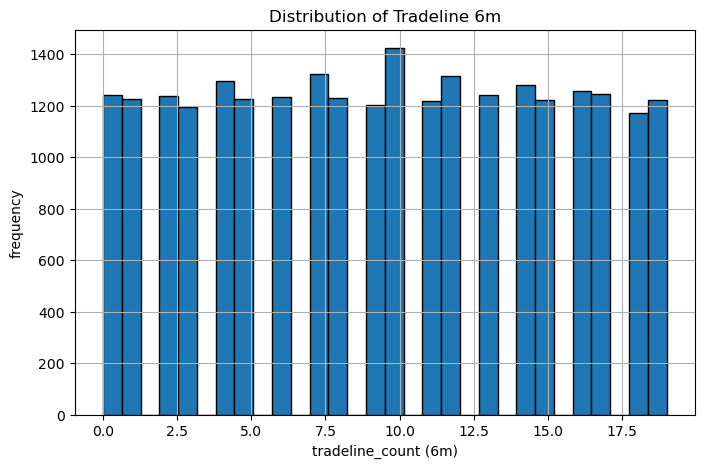

In [20]:
# visulization
plt.figure(figsize=(8, 5))
tradeline['Total_Tradelines_6m_In'].hist(bins=30, edgecolor='Black')
plt.title("Distribution of Tradeline 6m")
plt.xlabel("tradeline_count (6m)")
plt.ylabel("frequency")
plt.show


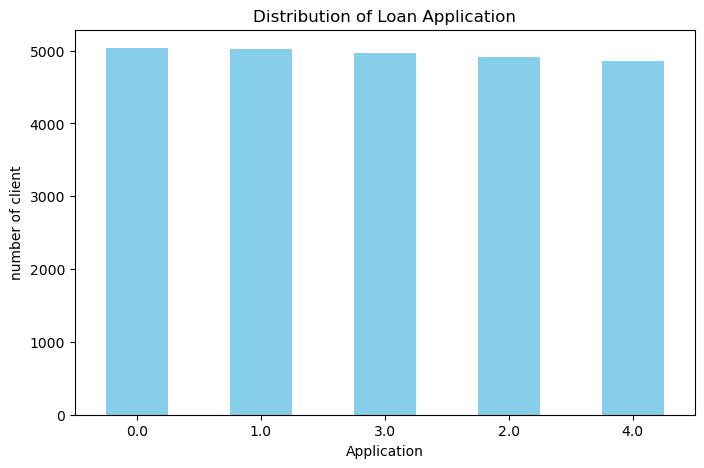

Total Client 24800
Total Applied clients 19765
Total Not Applied clients 5035
Applied Percentage 79.7%
Not Applied Percentage 20.3%
Total Application Applied
0.0    5035
1.0    5024
2.0    4917
3.0    4970
4.0    4854
Name: count, dtype: int64


In [21]:
# Distribution of Loan Application

total_clients = base['Client_ID'].nunique()
applied_clients = base[base['Applied'] > 0]['Client_ID'].nunique()
not_applied_client = base[base['Applied'] == 0]['Client_ID'].nunique()

applied_pct = round((applied_clients / total_clients)* 100, 2)
not_applied_pct = round((not_applied_client / total_clients) * 100, 2)

application_count = base['Applied'].value_counts().sort_index()


plt.figure(figsize=(8, 5))
base['Applied'].value_counts().plot(kind='bar', color='skyblue')
plt.title("Distribution of Loan Application")
plt.xlabel("Application")
plt.ylabel("number of client")
plt.xticks(rotation= 0)
plt.show()

print(f"Total Client {total_clients}")
print(f"Total Applied clients {applied_clients}")
print(f"Total Not Applied clients {not_applied_client}")
print(f"Applied Percentage {applied_pct}%")
print(f"Not Applied Percentage {not_applied_pct}%")
print(f"Total Application {application_count}")

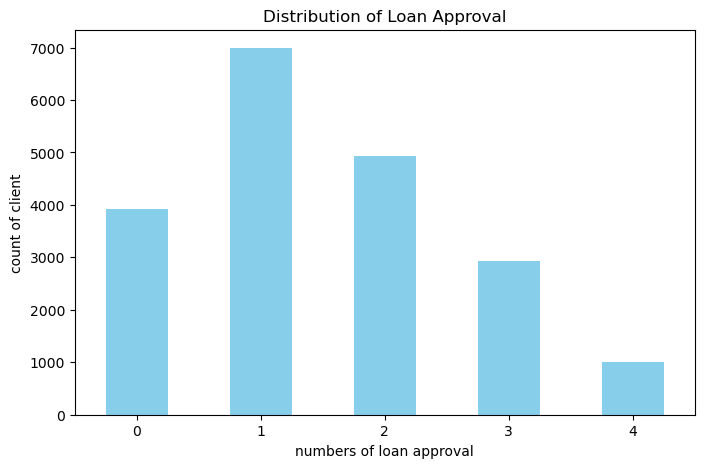

In [22]:
# Distribution of Loan Approval
import seaborn as sns

base['Approved_rate'] = base.apply(
    lambda row: round(row['Approved'] / row['Applied'], 2) if row['Applied'] > 0 else None, axis= 1
)

applied_data = base[base['Applied'] > 0]

plt.figure(figsize=(8, 5))
applied_data['Approved'].value_counts().sort_index().plot(
    kind='bar',
    color='Skyblue'
)
plt.title("Distribution of Loan Approval")
plt.xlabel("numbers of loan approval")
plt.ylabel("count of client")
plt.xticks(rotation=0)
plt.show()

In [23]:
# Distribution of Max_Trade_3m_out

mean_maxTrade = tradeline['Max_Trade_3m_Out'].mean()
median_maxTrade = tradeline['Max_Trade_3m_Out'].median()
std_maxTrade = tradeline['Max_Trade_3m_Out'].std()

# maxTrade_outliers
Q1_max = tradeline['Max_Trade_3m_Out'].quantile(0.25)
Q3_max = tradeline['Max_Trade_3m_Out'].quantile(0.75)

IQR_max = Q3_max - Q1_max

maxTrade_upper = Q3_max + 1.5 * IQR_max
maxTrade_lower = Q1_max - 1.5 * IQR_max

maxTrade_outliers = tradeline.loc[
    ((tradeline['Max_Trade_3m_Out'] < maxTrade_lower) |
     (tradeline['Max_Trade_3m_Out'] > maxTrade_upper))
]

maxTrade_num_outliers = maxTrade_outliers['Client_ID'].nunique()

print("Statistics")
print(f"Mean of MaxTrade: {mean_maxTrade}")
print(f"Median of MaxTrade: {median_maxTrade}")
print(f"STD of MaxTrade: {std_maxTrade}")
print(f"Outliers: {maxTrade_num_outliers}")

Statistics
Mean of MaxTrade: 10471.49164
Median of MaxTrade: 10429.0
STD of MaxTrade: 5498.743149376866
Outliers: 0


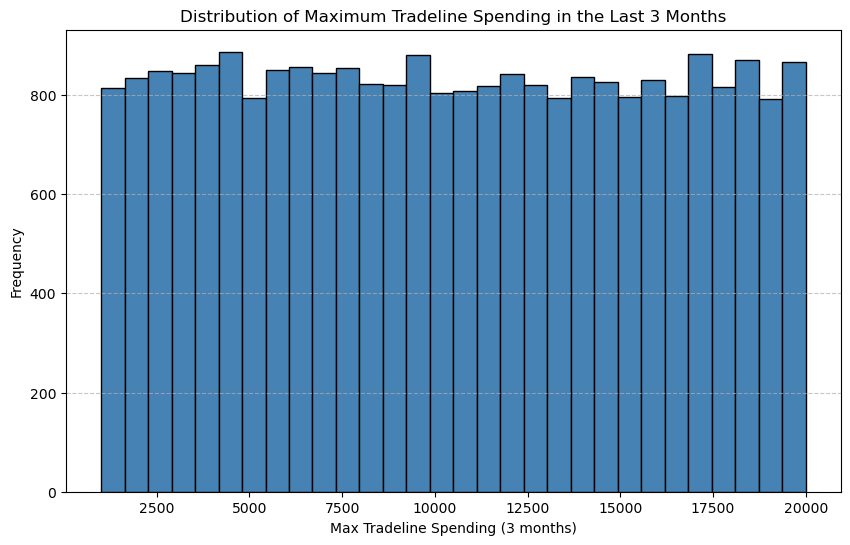

In [24]:
# visulization
plt.figure(figsize=(10, 6))
plt.hist(tradeline['Max_Trade_3m_Out'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Maximum Tradeline Spending in the Last 3 Months")
plt.xlabel("Max Tradeline Spending (3 months)")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [25]:
# Spread of Tradeline 1y 
mean_tradeline_1y = tradeline['Total_Tradelines_1y_In'].mean()
median_tradeline_1y = tradeline['Total_Tradelines_1y_In'].median()
std_tradeline_1y = tradeline['Total_Tradelines_1y_In'].std()

Q1_tradeline_1y = tradeline['Total_Tradelines_1y_In'].quantile(0.25)
Q3_tradeline_1y = tradeline['Total_Tradelines_1y_In'].quantile(0.75)

IQR_tradeline_1y = Q3_tradeline_1y - Q1_tradeline_1y

Trade_1y_upper = Q3_tradeline_1y + 1.5 * IQR_tradeline_1y
Trade_1y_lower = Q1_tradeline_1y - 1.5 * IQR_tradeline_1y

Tradeline_1y_outliers = tradeline.loc[
    ((tradeline['Total_Tradelines_1y_In'] < Trade_1y_lower) |
     (tradeline['Total_Tradelines_1y_In'] > Trade_1y_upper))
]

Trade_num_outliers = Tradeline_1y_outliers['Client_ID'].nunique()

print("Statistics")
print(f"Mean of Tradeline_1y: {mean_tradeline_1y}")
print(f"Median of Tradeline_1y: {median_tradeline_1y}")
print(f"STD of Tradeline: {std_tradeline_1y}")
print(f"Outliers: {Trade_num_outliers}")

Statistics
Mean of Tradeline_1y: 18.13032
Median of Tradeline_1y: 18.0
STD of Tradeline: 6.279251058633691
Outliers: 0


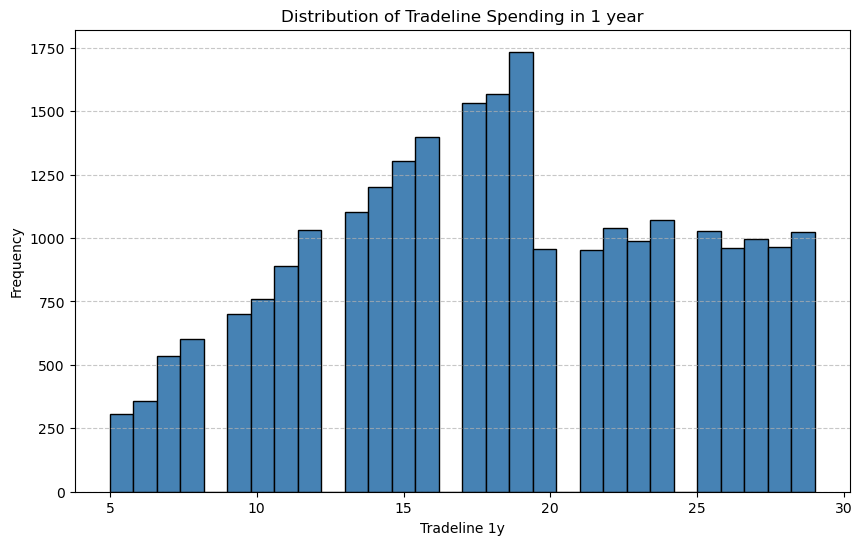

In [26]:
# Visulizarion

plt.figure(figsize=(10, 6))
plt.hist(tradeline['Total_Tradelines_1y_In'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Tradeline Spending in 1 year")
plt.xlabel("Tradeline 1y")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

In [27]:
# Spread of Total Enquiry 1y
mean_enquiry_1y = enquiry['Total_Enquiry_1y_In'].mean()
median_enquiry_1y = enquiry['Total_Enquiry_1y_In'].median()
std_enquiry_1y = enquiry['Total_Enquiry_1y_In'].std()

Q1_enquiry_1y = enquiry['Total_Enquiry_1y_In'].quantile(0.25)
Q3_enquiry_1y = enquiry['Total_Enquiry_1y_In'].quantile(0.75)

IQR_enquiry_1y = Q3_enquiry_1y - Q1_enquiry_1y

enquiry_1y_upper = Q3_enquiry_1y + 1.5 * IQR_enquiry_1y
enquiry_1y_lower = Q1_enquiry_1y - 1.5 * IQR_enquiry_1y

enquiry_1y_outliers = enquiry.loc[
    ((enquiry['Total_Enquiry_1y_In'] < enquiry_1y_lower) |
     (enquiry['Total_Enquiry_1y_In'] > enquiry_1y_upper))
]

enquiry_num_outliers = enquiry_1y_outliers['Client_ID'].nunique()

print("Statistics")
print(f"Mean of Enquiry_1y: {mean_enquiry_1y}")
print(f"Median of Enquiry_1y: {median_enquiry_1y}")
print(f"STD of Enquiry: {std_enquiry_1y}")
print(f"Outliers: {Trade_num_outliers}")

Statistics
Mean of Enquiry_1y: 14.372897959183673
Median of Enquiry_1y: 14.0
STD of Enquiry: 5.531962071561176
Outliers: 0


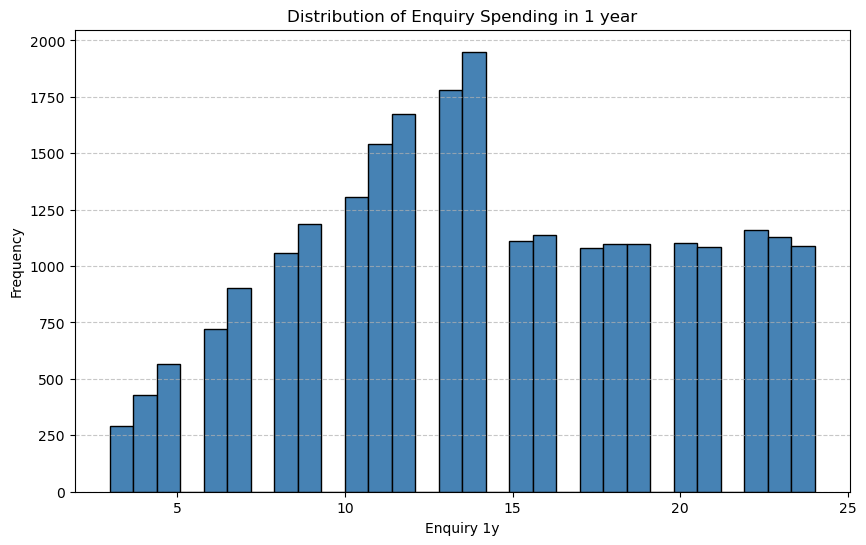

In [28]:
# Visulizarion

plt.figure(figsize=(10, 6))
plt.hist(enquiry['Total_Enquiry_1y_In'], bins=30, color='steelblue', edgecolor='black')
plt.title("Distribution of Enquiry Spending in 1 year")
plt.xlabel("Enquiry 1y")
plt.ylabel("Frequency")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Data Exploration & Bivariate Analysis

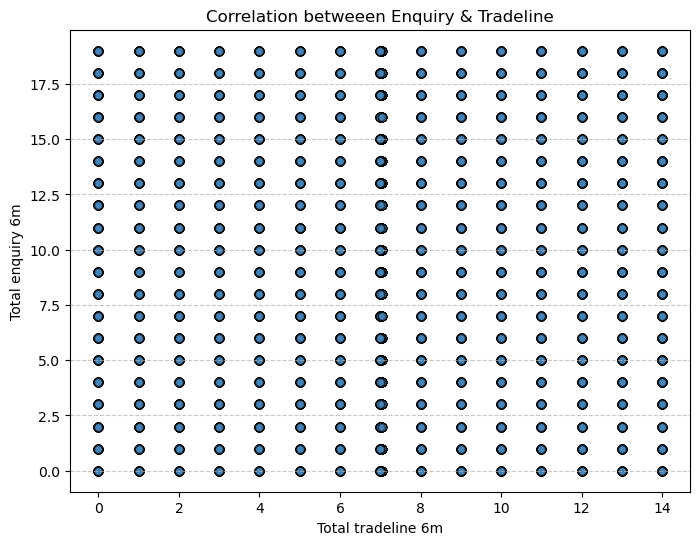

Correlation: 0.01


In [29]:
# credit behavior through of correlation

merge = pd.merge(enquiry, tradeline, on='Client_ID', how='inner')

correlation_6m = merge['Total_Enquiry_6m_In'].corr(merge['Total_Tradelines_6m_In'])

plt.figure(figsize=(8, 6))
plt.scatter(merge['Total_Enquiry_6m_In'], merge['Total_Tradelines_6m_In'], 
            color='steelblue', alpha=0.6, edgecolor='black')
plt.title("Correlation betweeen Enquiry & Tradeline")
plt.xlabel("Total tradeline 6m")
plt.ylabel("Total enquiry 6m")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Correlation:", round(correlation_6m, 2))

Average Applied more: 1.97
Average applied less: 1.99


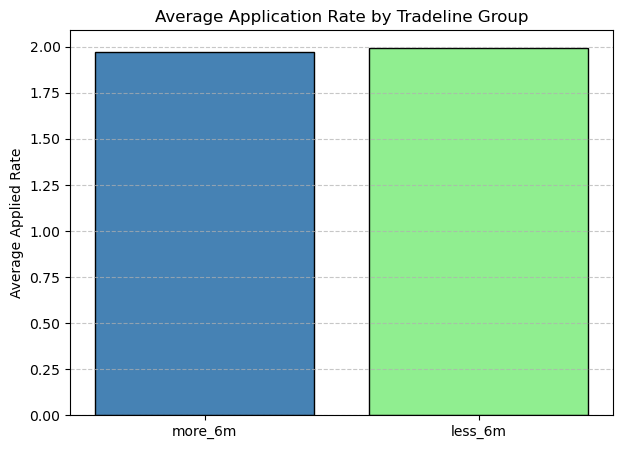

In [30]:
# Loan Application Behavior

merge_2 = pd.merge(tradeline, base, on='Client_ID', how='inner')

median_tradeline_6m = merge_2['Total_Tradelines_6m_In'].median()

more_6m = merge_2[merge_2['Total_Tradelines_6m_In'] > median_tradeline_6m]
less_6m = merge_2[merge_2['Total_Tradelines_6m_In'] < median_tradeline_6m]

avg_applied_more = round(more_6m['Applied'].mean(), 2)
avg_applied_less = round(less_6m['Applied'].mean(), 2)

print(F"Average Applied more: {avg_applied_more}")
print(f"Average applied less: {avg_applied_less}")

plt.figure(figsize=(7,5))
plt.bar(['more_6m', 'less_6m'],
        [avg_applied_more, avg_applied_less],
        color=['steelblue','lightgreen'], edgecolor='black')
plt.title("Average Application Rate by Tradeline Group")
plt.ylabel("Average Applied Rate")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

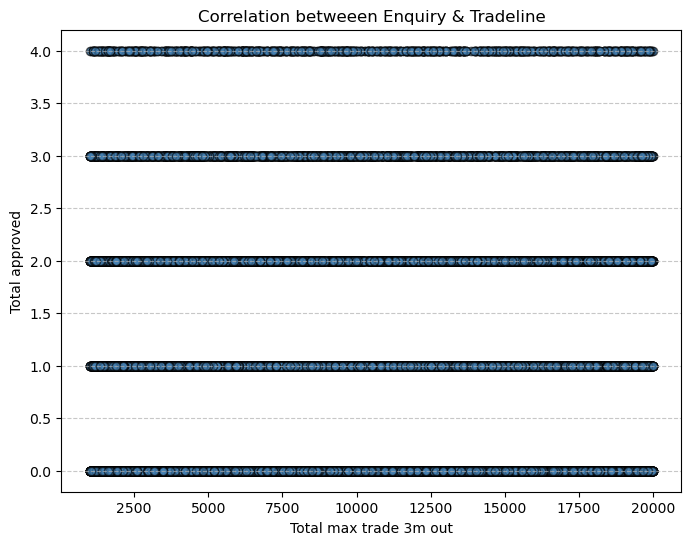

Correlation: -0.0


In [31]:
# understanding Loan Approvals
correlation_3m = merge_2['Max_Trade_3m_Out'].corr(merge_2['Approved'])

plt.figure(figsize=(8, 6))
plt.scatter(merge_2['Max_Trade_3m_Out'], merge_2['Approved'], 
            color='steelblue', alpha=0.6, edgecolor='black')
plt.title("Correlation betweeen Enquiry & Tradeline")
plt.xlabel("Total max trade 3m out")
plt.ylabel("Total approved")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Correlation:", round(correlation_3m, 2))

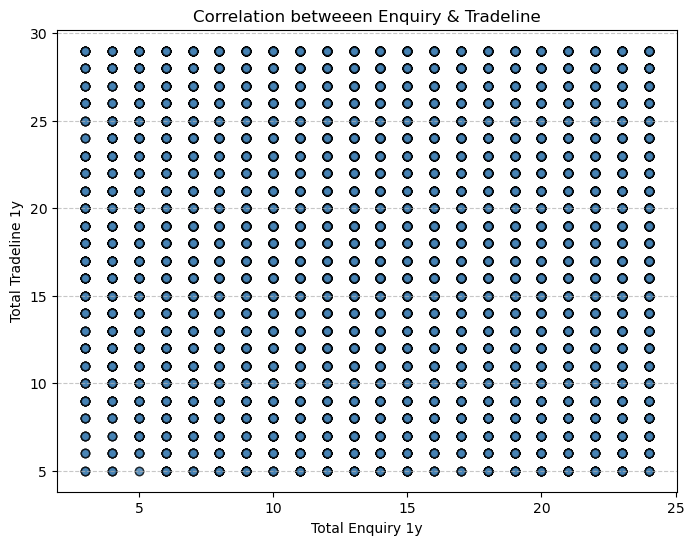

Correlation: 0.0


In [32]:
#Enquries and Tradeline behaviors

correlation_1y = merge['Total_Enquiry_1y_In'].corr(merge['Total_Tradelines_1y_In'])

plt.figure(figsize=(8, 6))
plt.scatter(merge['Total_Enquiry_1y_In'], merge['Total_Tradelines_1y_In'], 
            color='steelblue', alpha=0.6, edgecolor='black')
plt.title("Correlation betweeen Enquiry & Tradeline")
plt.xlabel("Total Enquiry 1y")
plt.ylabel("Total Tradeline 1y")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Correlation:", round(correlation_1y, 2))

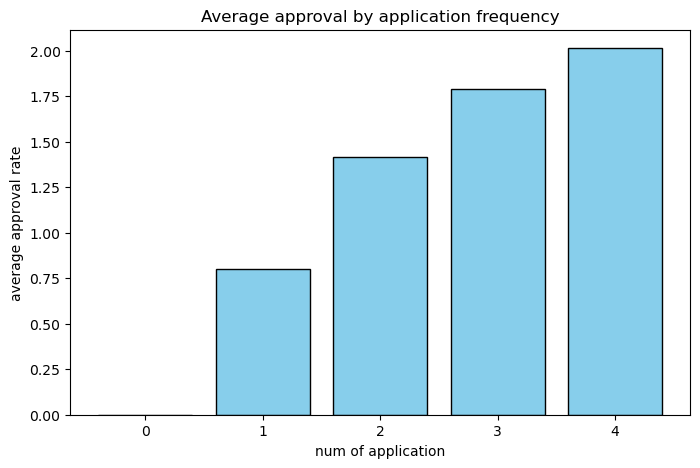

In [85]:
# Analyzing Loan Approval with Loan Applications

Application_frq = base.groupby('Client_ID')['Applied'].sum().reset_index()
Application_frq.rename(columns={'Applied': 'Application_frequency'}, inplace=True)

frq_merge = pd.merge(base, Application_frq, on='Client_ID', how='inner')

Avg_approval = frq_merge.groupby('Application_frequency')['Approved'].mean().reset_index()

plt.figure(figsize=(8, 5))
plt.bar(Avg_approval['Application_frequency'], Avg_approval['Approved'], color='skyblue', edgecolor='black')
plt.title("Average approval by application frequency")
plt.xlabel("num of application")
plt.ylabel("average approval rate")
plt.xticks(rotation=0)
plt.show()

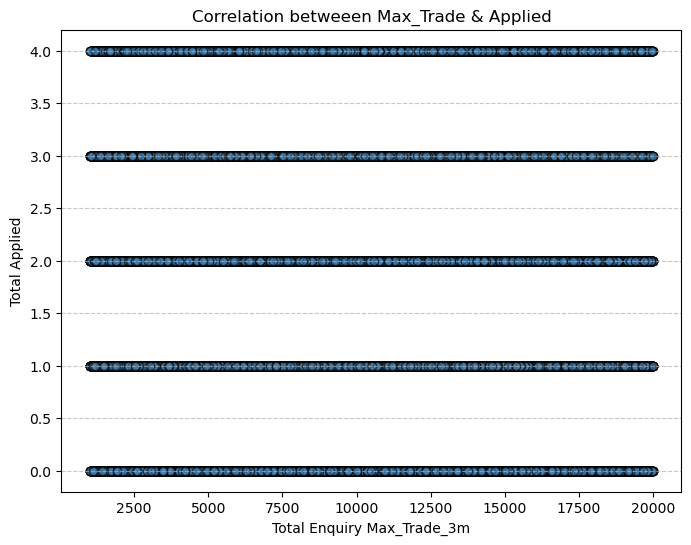

Correlation: 0.0


In [34]:
# Spending corr with Loan Application

correlation_3m_out = merge_2['Max_Trade_3m_Out'].corr(merge_2['Applied'])

plt.figure(figsize=(8, 6))
plt.scatter(merge_2['Max_Trade_3m_Out'], merge_2['Applied'], 
            color='steelblue', alpha=0.6, edgecolor='black')
plt.title("Correlation betweeen Max_Trade & Applied")
plt.xlabel("Total Enquiry Max_Trade_3m")
plt.ylabel("Total Applied")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

print("Correlation:", round(correlation_3m_out, 2))

Feature Engineering

C:\Users\Nayan\AppData\Local\Temp\ipykernel_10292\4177586340.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  base['Approved_rate'].replace([np.nan, np.inf, -np.inf], 0, inplace=True)


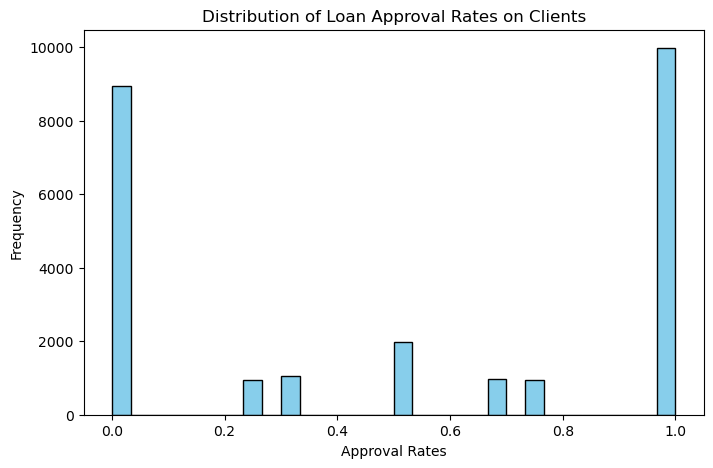

Mean Approval_Rate:0.52


In [35]:
# Asscessing Loan Approval Process

import numpy as np 

base['Approved_rate'].replace([np.nan, np.inf, -np.inf], 0, inplace=True)
base['Approved_rate']

plt.figure(figsize=(8, 5))
plt.hist(base['Approved_rate'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Loan Approval Rates on Clients")
plt.xlabel("Approval Rates")
plt.ylabel("Frequency")
plt.show()

mean_approval = round((base['Approved_rate'].mean()), 2)
print(f"Mean Approval_Rate:{mean_approval}")

C:\Users\Nayan\AppData\Local\Temp\ipykernel_10292\2083051122.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  tradeline['Credit_Utilization'].replace([np.nan, np.inf, -np.inf], 0, inplace=True)


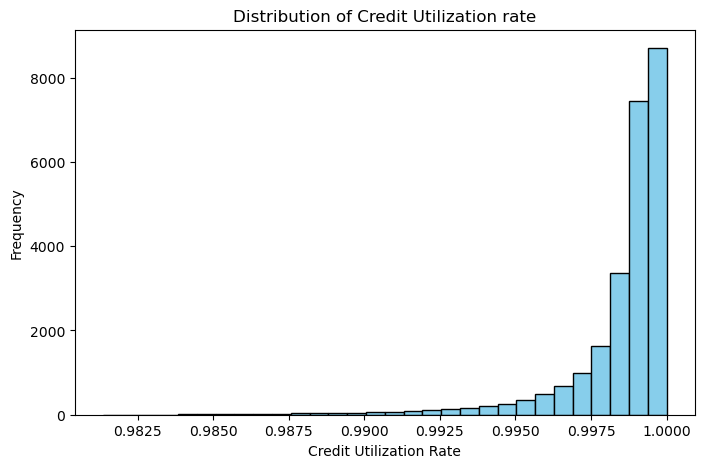

Average Credit Utilization Rate: 1.0


In [36]:
# Understanding Credit Utilization

tradeline['Credit_Utilization'] = tradeline.apply(
    lambda row: row['Max_Trade_3m_Out'] / (row['Total_Tradelines_6m_In'] + row['Max_Trade_3m_Out']) 
    if (row['Total_Tradelines_6m_In'] + row['Max_Trade_3m_Out']) > 0 else 0, axis=1
)

tradeline['Credit_Utilization'].replace([np.nan, np.inf, -np.inf], 0, inplace=True)

plt.figure(figsize=(8, 5))
plt.hist(tradeline['Credit_Utilization'], bins=30, color='skyblue', edgecolor='black')
plt.title("Distribution of Credit Utilization rate")
plt.xlabel("Credit Utilization Rate")
plt.ylabel("Frequency")
plt.show()

mean_credit_utilization = round((tradeline['Credit_Utilization'].mean()), 2)

print(f"Average Credit Utilization Rate: {mean_credit_utilization}")

   Client_category  Client_count
0     Low Activity          7419
1  Medium Activity         12689
2    High Activity          4892


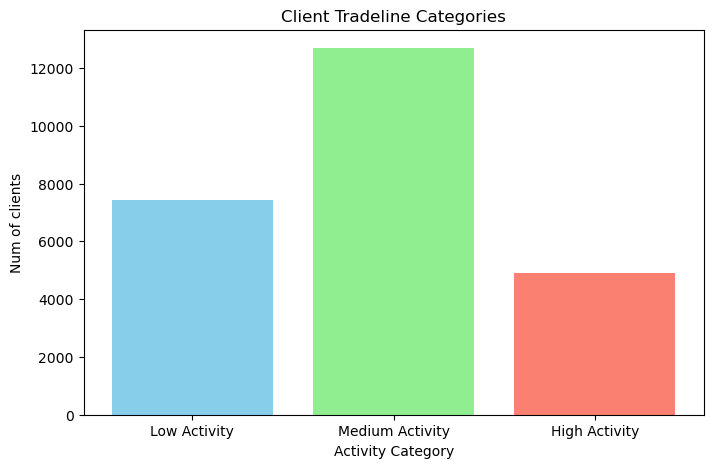

In [37]:
# Segmenting Client on credit behaviour

def classify_client(x):
    if 0 <= x <= 5:
        return 'Low Activity'
    elif 6 <= x <= 15:
        return 'Medium Activity'
    else:
        return 'High Activity'
    
tradeline['Client_category'] = tradeline['Total_Tradelines_6m_In'].apply(classify_client)

Category_count = tradeline['Client_category'].value_counts().reindex(
    ['Low Activity', 'Medium Activity', 'High Activity']
).reset_index()
Category_count.columns = ['Client_category', 'Client_count']

print(Category_count)

plt.figure(figsize=(8, 5))
plt.bar(Category_count['Client_category'], Category_count['Client_count'], color=['skyblue', 'lightgreen', 'salmon'])
plt.title("Client Tradeline Categories")
plt.xlabel("Activity Category")
plt.ylabel("Num of clients")
plt.show()

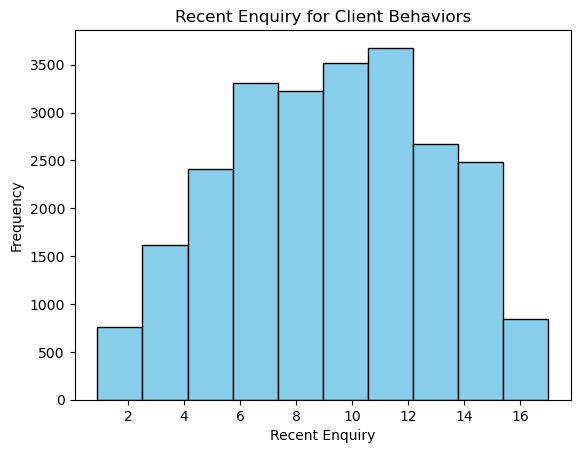

Average Recent Enquiries: 9.24


In [38]:
# Recent Enquiry of Credit behaviors

enquiry['Recent_Enquiry'] = (enquiry['Total_Enquiry_6m_In'] * 0.7) + (enquiry['Total_Enquiry_1y_In'] * 0.3)

plt.Figure(figsize=(8, 5))
plt.hist(enquiry['Recent_Enquiry'], color='skyblue', edgecolor='black')
plt.title("Recent Enquiry for Client Behaviors")
plt.xlabel("Recent Enquiry")
plt.ylabel("Frequency")
plt.show()

mean_recent_enquiry = round((enquiry['Recent_Enquiry'].mean()), 2)
print(f"Average Recent Enquiries: {mean_recent_enquiry}")


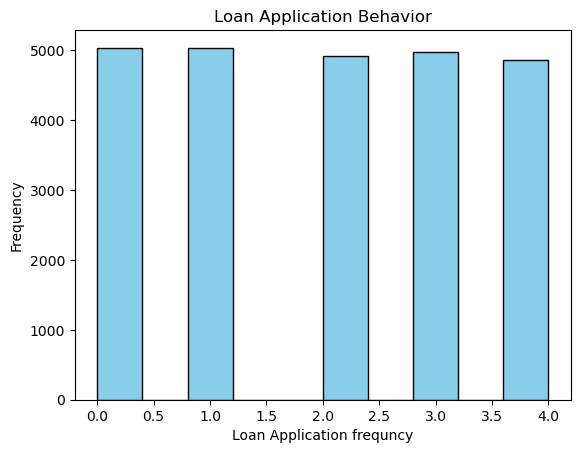

Average Loan Application Frequency: 1.98


In [39]:
# Clients loan application behaviors

Application_frq

plt.Figure(figsize=(8, 6))
plt.hist(Application_frq['Application_frequency'], color='skyblue', edgecolor='black')
plt.title("Loan Application Behavior")
plt.xlabel("Loan Application frequncy")
plt.ylabel("Frequency")
plt.show()

mean_application_frq = round((Application_frq['Application_frequency'].mean()), 2)
print(f"Average Loan Application Frequency: {mean_application_frq}")

Risk_Indicator
High Risk      16747
Medium Risk     4859
Low Risk        2894
Name: count, dtype: int64


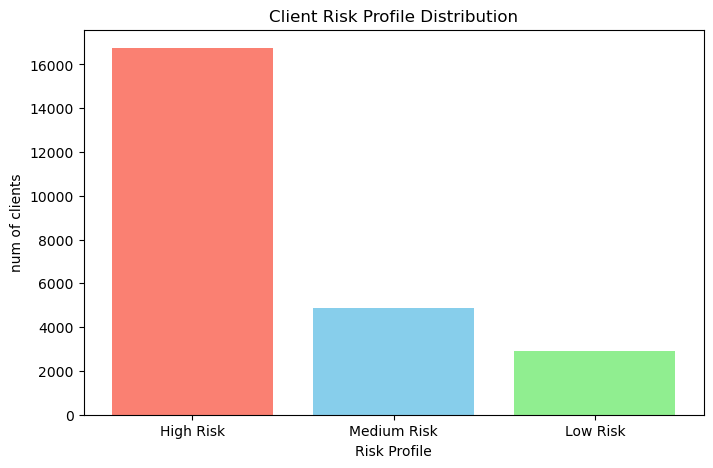

In [40]:
# Client Risk Profile
def risk_profile(row):
    if row['Total_Enquiry_6m_In'] <= 5 and row['Total_Tradelines_6m_In'] <= 5:
        return "Low Risk"
    elif row['Total_Enquiry_6m_In'] <= 5 and row['Total_Tradelines_6m_In'] <= 15:
        return "Medium Risk"
    else:
        return "High Risk"
    
merge['Risk_Indicator'] = merge.apply(risk_profile, axis=1)

risk_count = merge['Risk_Indicator'].value_counts().reindex(
    ['High Risk', 'Medium Risk', 'Low Risk']
)
risk_count.columns = ['Risk_Indicator', 'Client_count']
print(risk_count)

plt.figure(figsize=(8, 5))
plt.bar(risk_count.index, risk_count.values, color=['salmon', 'skyblue', 'lightgreen'])
plt.title("Client Risk Profile Distribution")
plt.xlabel("Risk Profile")
plt.ylabel("num of clients")
plt.show()

Advanced Analysis

  Risk_profile  Approved_rate
0    High Risk       0.518925
1     Low Risk       0.520409
2  Medium Risk       0.527662


C:\Users\Nayan\AppData\Local\Temp\ipykernel_10292\2487006170.py:12: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  merge_2['Approved_rate'].replace([np.nan, np.inf, -np.inf], 0, inplace=True)


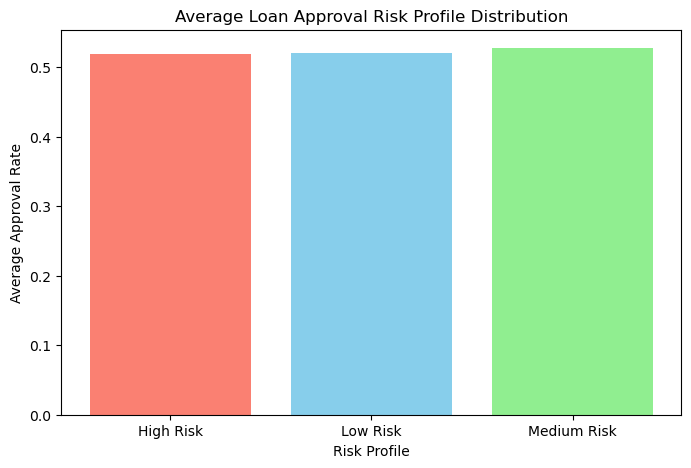

In [41]:
# High Risk Clients based on credit behaviors and spending

def Risk_Indicator(row):
    if row['Total_Tradelines_6m_In'] > 10 and row['Max_Trade_3m_Out'] > 5000:
        return "High Risk"
    elif 5 <= row['Total_Tradelines_6m_In'] <= 10 and 2000 <= row['Max_Trade_3m_Out'] <= 5000:
        return "Medium Risk"
    else:
        return "Low Risk"

merge_2['Risk_profile'] = merge_2.apply(Risk_Indicator, axis=1)
merge_2['Approved_rate'].replace([np.nan, np.inf, -np.inf], 0, inplace=True)

Avg_approval_Risk = merge_2.groupby('Risk_profile')['Approved_rate'].mean().reset_index()
print(Avg_approval_Risk)


plt.figure(figsize=(8, 5))
plt.bar(Avg_approval_Risk['Risk_profile'], Avg_approval_Risk['Approved_rate'], color=['salmon', 'skyblue', 'lightgreen'])
plt.title("Average Loan Approval Risk Profile Distribution")
plt.xlabel("Risk Profile")
plt.ylabel("Average Approval Rate")
plt.show()


  Tradeline_Risk  Application_rate
0      High Risk              0.80
1       Low Risk              0.79
2    Medium Risk              0.80


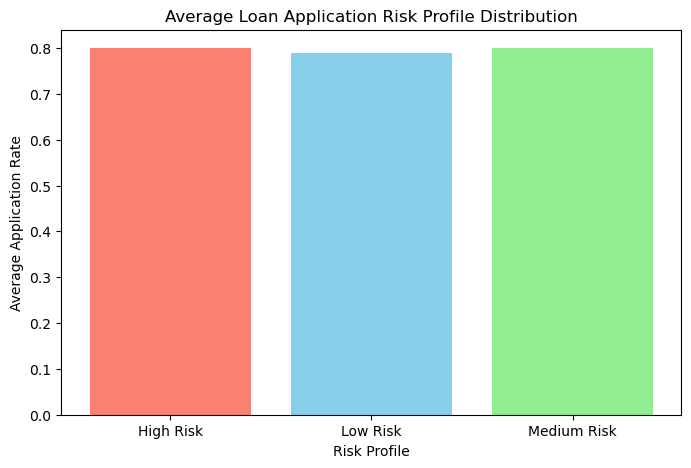

In [49]:
# Loan Application Patterns based on Credit Activity

def Tradeline_Risk(x):
    if x <= 5:
        return "Low Risk"
    elif 5 < x <= 15:
        return "Medium Risk"
    else:
        return 'High Risk'

merge_2['Tradeline_Risk'] = merge_2['Total_Tradelines_6m_In'].apply(Tradeline_Risk)

merge_2['Application_rate'] = merge_2.apply(
    lambda row: row['Applied'] / row['Applied'] if row['Applied'] > 0 else 0, axis=1
)

Average_Application_rate = merge_2.groupby('Tradeline_Risk')['Application_rate'].mean().round(2).reset_index()
print(Average_Application_rate)

plt.figure(figsize=(8, 5))
plt.bar(Average_Application_rate['Tradeline_Risk'], Average_Application_rate['Application_rate'], color=['salmon', 'skyblue', 'lightgreen'])
plt.title("Average Loan Application Risk Profile Distribution")
plt.xlabel("Risk Profile")
plt.ylabel("Average Application Rate")
plt.show()

Average  Approval Rate:      Max_Risk  Approval_rate
0    High Risk           0.52
1     Low Risk           0.56
2  Medium Risk           0.52


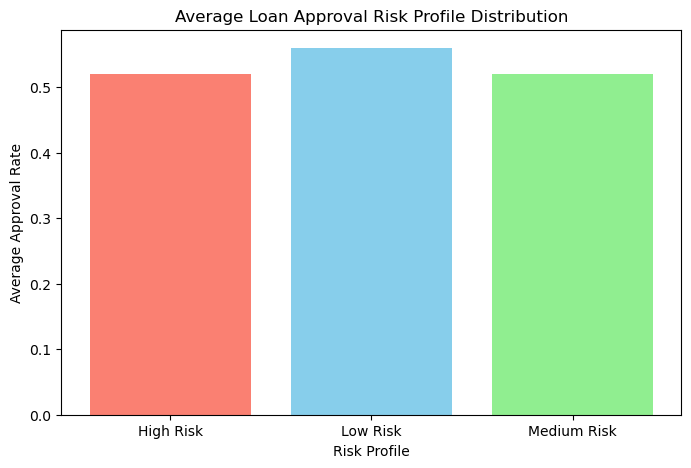

In [65]:
# Impact of spending Behavior on Loan Approval

def Max_Risk(x):
    if x <= 2000:
        return "Low Risk"
    elif 2000 < x <= 5000:
        return "Medium Risk"
    else:
        return 'High Risk'

merge_2['Max_Risk'] = merge_2['Max_Trade_3m_Out'].apply(Max_Risk)

merge_2['Approval_rate'] = merge_2.apply(
    lambda row: row['Approved'] / row['Applied'] if row['Applied'] > 0 else 0, axis=1
)

merge_2['Approval_rate'].replace([np.nan, np.inf, -np.inf], 0)

Average_Approval_Rate = merge_2.groupby('Max_Risk')['Approval_rate'].mean().round(2).reset_index()
print(f"Average  Approval Rate:{Average_Approval_Rate}")

plt.figure(figsize=(8, 5))
plt.bar(Average_Approval_Rate['Max_Risk'], Average_Approval_Rate['Approval_rate'], color=['salmon', 'skyblue', 'lightgreen'])
plt.title("Average Loan Approval Risk Profile Distribution")
plt.xlabel("Risk Profile")
plt.ylabel("Average Approval Rate")
plt.show()


   frq_categories  Approved_rate
0  High Frequency           0.55
1   Low Frequency           0.50


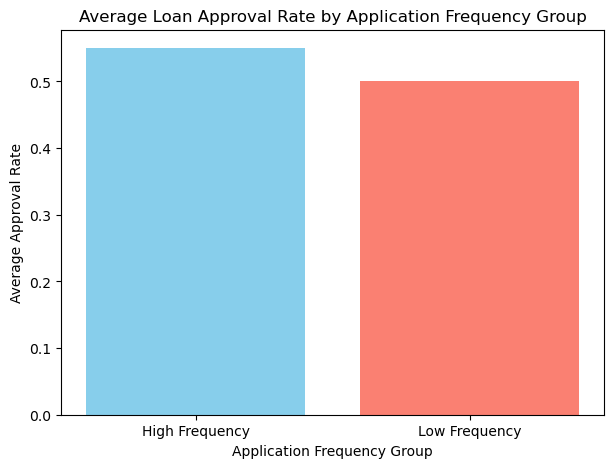

In [ ]:
# Client segmention with high loan Application

median_frq = Application_frq['Application_frequency'].median()

Application_frq['frq_categories'] = Application_frq['Application_frequency'].apply(
    lambda x: "High Frequency" if x > median_frq else "Low Frequency" 
)

frq_merge = pd.merge(base, Application_frq, on='Client_ID', how='inner')
frq_merge['Approved_rate'].replace([np.nan, np.inf, -np.inf], 0)

Average_Approval_Rate_frq = frq_merge.groupby('frq_categories')['Approved_rate'].mean().round(2).reset_index()
print(Average_Approval_Rate_frq)

plt.figure(figsize=(7,5))
plt.bar(Average_Approval_Rate_frq['frq_categories'], Average_Approval_Rate_frq['Approved_rate'], 
        color=['skyblue','salmon'])
plt.title("Average Loan Approval Rate by Application Frequency Group")
plt.xlabel("Application Frequency Group")
plt.ylabel("Average Approval Rate")
plt.show()

  Classified_Engagement  Approval_rate
0        Engaged Client       0.520792
1   Less Engaged Client       0.527332
2                 Other       0.518338


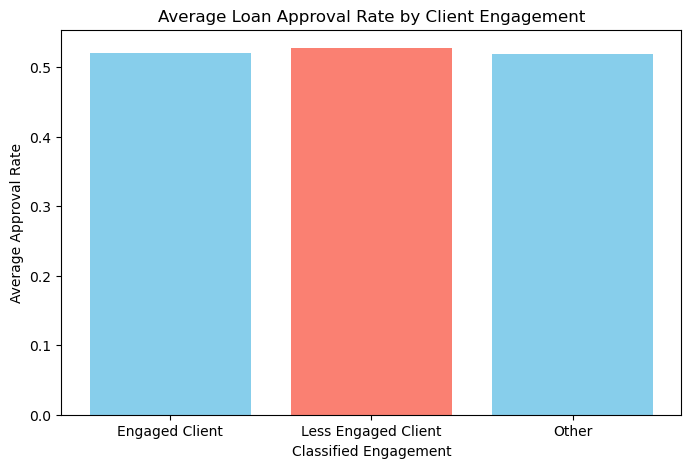

In [130]:
# Link between Loan approvals and client engagement

def engagement(row):
    if row['Total_Tradelines_6m_In'] > 5 and row['Total_Enquiry_6m_In'] > 5:
        return 'Engaged Client'
    elif row['Total_Tradelines_6m_In'] <= 5 and row['Total_Enquiry_6m_In'] <= 5:
        return 'Less Engaged Client'
    else:
        return 'Other'

merge_4 = pd.merge(merge_2, enquiry, on='Client_ID')
    
merge_4['Classified_Engagement'] = merge_4.apply(engagement, axis=1)

Average_Approval_Rate = merge_4.groupby('Classified_Engagement')['Approval_rate'].mean().reset_index()
print(Average_Approval_Rate)


plt.figure(figsize=(8,5))
plt.bar(Average_Approval_Rate['Classified_Engagement'], Average_Approval_Rate['Approval_rate'], 
        color=['skyblue','salmon'])
plt.title("Average Loan Approval Rate by Client Engagement")
plt.xlabel("Classified Engagement")
plt.ylabel("Average Approval Rate")
plt.show()